In [ ]:
import torch
import sys
from sweep.propagator.torch import PropTorch
from sweep.equations import Acoustic
from sweep.signal import ricker
import numpy as np
import matplotlib.pyplot as plt

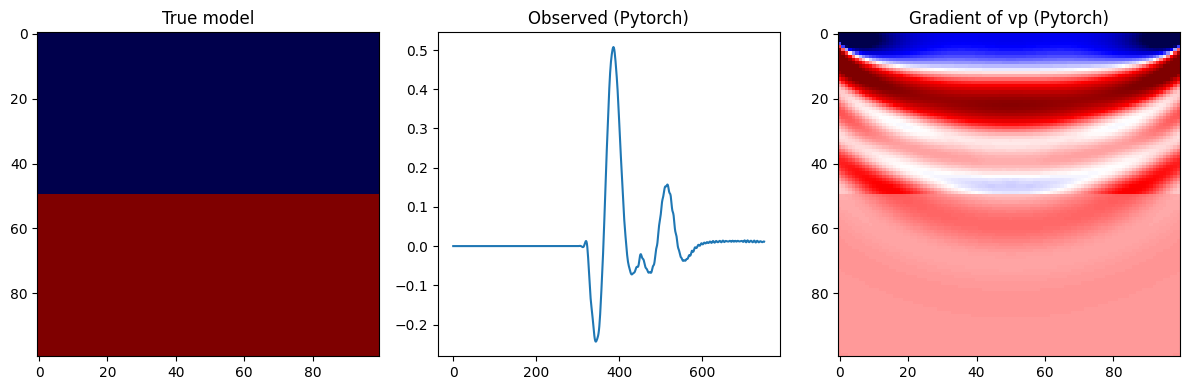

In [2]:
# Model parameters
nt = 1500
dt = 0.002
dh = 10
delay = 0.1
fm = 5
spatial_order = 8
shape = (100,100)

# Device
dev = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Create a 2-layer velocity model
true_model = np.ones(shape, dtype=np.float32)*1500
true_model[50:, :] = 2000

eq_kwargs = dict(spatial_order=spatial_order, device=dev)
solver_kwargs = dict(shape=shape, dev=dev, dh=dh, dt=dt, source_type=['h1'], receiver_type=['h1'], abcn=30, free_surface=False, pml_type='cpmlr', use_ckpt=False)
# Create a solver_torch
solver_torch = PropTorch(Acoustic(**eq_kwargs, backend='torch'), **solver_kwargs)

# Create a wavelet
t = np.arange(0, int(nt//2)*dt, dt)
wave = ricker(t-delay, f=fm)

# Acquicition geometry
sources = np.array([[1, 1]]) # in grid, shape=(nshots, 2)
receivers = np.array([[[99, 1]]]) # in grid, shape=(nshots, nreceivers, 2)

# Forward modeling
vp = torch.from_numpy(true_model).to(dev).requires_grad_(True)
# Backward propagation (Pytorch)
obs_torch = solver_torch(wave, sources, receivers, models=[vp])
obs_torch.pow(2).sum().backward()
grad_torch = vp.grad.detach().cpu().numpy()  # Pytorch


# Show the results
fig, axes=plt.subplots(1,3, figsize=(12,4))

axes[0].imshow(true_model, cmap='seismic', aspect='auto')
axes[0].set_title('True model')

axes[1].plot(obs_torch.detach().cpu().numpy().squeeze(), label='Observed data')
vmin,vmax=np.percentile(grad_torch, [1,99])
axes[1].set_title('Observed (Pytorch)')
axes[2].imshow(grad_torch, cmap='seismic', aspect='auto', vmin=vmin, vmax=vmax)
axes[2].set_title('Gradient of vp (Pytorch)')

fig.tight_layout()
plt.savefig('fwi_torch.png', dpi=300, bbox_inches='tight')
plt.show()